#### What is a Strip Plot (stripplot)?
A strip plot is a type of graph used to show the distribution of a continuous numerical variable across the different levels of a categorical variable. It represents each observation as a dot along a line (or "strip") corresponding to its category.

Its main feature is that it plots every single data point, which allows you to see the full distribution of the data without any summarization.

The biggest challenge with a strip plot is that if multiple data points have the same value, they will be plotted on top of each other, making it hard to see the true density. To solve this, a small amount of random "jitter" is often added to the points along the categorical axis to spread them out and make them visible.

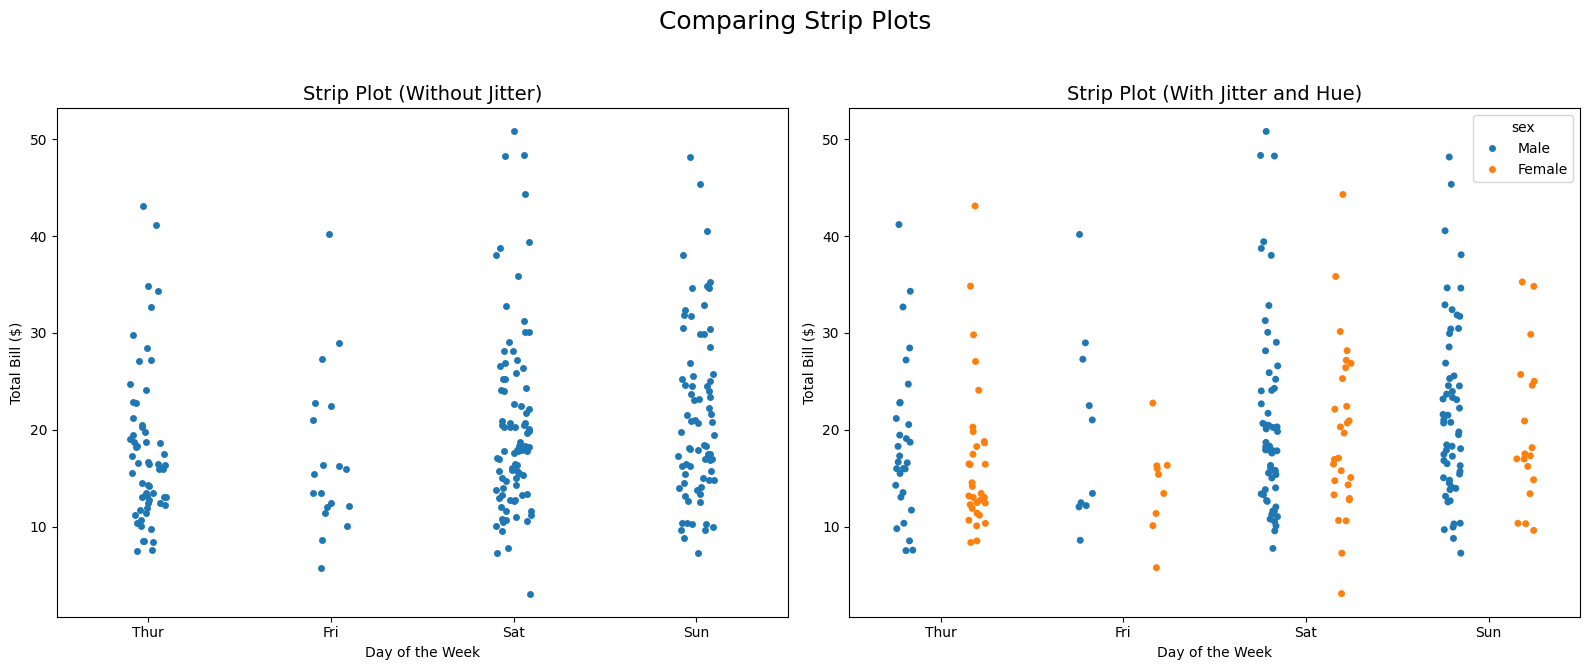

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sample Data
# Load the built-in 'tips' dataset from Seaborn
df = sns.load_dataset('tips')

# 2. Sample Code for the Plot

# Create a figure with two subplots to show the effect of jitter
fig, axes = plt.subplots(1, 2, figsize=(16, 7))


# --- Plot 1: Strip Plot WITHOUT Jitter ---
# This shows the problem of overplotting.
sns.stripplot(
    data=df,
    x='day',
    y='total_bill',
    ax=axes[0]
)
axes[0].set_title('Strip Plot (Without Jitter)', fontsize=14)
axes[0].set_xlabel('Day of the Week')
axes[0].set_ylabel('Total Bill ($)')


# --- Plot 2: Strip Plot WITH Jitter and Hue ---
# Jitter spreads the points out horizontally to prevent overlap.
# Hue adds a second categorical dimension.
sns.stripplot(
    data=df,
    x='day',
    y='total_bill',
    hue='sex', # Color the points by the 'sex' of the tipper
    jitter=True, # Add random noise to the x-position
    dodge=True, # Separate the 'hue' categories along the x-axis
    ax=axes[1]
)
axes[1].set_title('Strip Plot (With Jitter and Hue)', fontsize=14)
axes[1].set_xlabel('Day of the Week')
axes[1].set_ylabel('Total Bill ($)')


plt.suptitle('Comparing Strip Plots', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### What Type of Information It Provides
A strip plot gives you a raw, un-summarized view of the data's distribution.

- Distribution and Density: You can see where the data points are concentrated for each category. Dense clusters of points indicate a high frequency of those values.

- Range and Spread: It clearly shows the minimum and maximum values for each category, giving you a sense of the overall spread.

- Outliers: Individual points that are far away from the main cluster for a category are easily identifiable as potential outliers.

- Comparison Across Categories: Its primary purpose is to allow for a quick visual comparison. In our example, you can see that the total_bill tends to be higher on Saturday and Sunday compared to Thursday and Friday.

- Underlying Sample Size: The number of dots in each strip gives you a rough idea of how many data points are in each category.



#### Scenarios for Using a Strip Plot
- During Exploratory Data Analysis (EDA)
Visualizing Numerical vs. Categorical Data: This is its main use case. It's a great first step to see how a numerical variable is distributed across different groups.
- When the Dataset is Small: A strip plot is most effective when you have a small to medium-sized dataset. With too much data, the points will overlap even with jitter, making the plot unreadable.
To See All Raw Data: When you want to see every single data point without any statistical summarization (unlike a box plot), a strip plot is the perfect choice.
-  As a Companion to Other Plots
A powerful technique is to overlay a strip plot on top of a box plot or violin plot. This gives you the best of both worlds: the statistical summary from the box/violin plot and the raw data points from the strip plot.

C:\Users\VimalS\AppData\Local\Temp\ipykernel_18976\3628348465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='day', y='total_bill', palette='pastel')


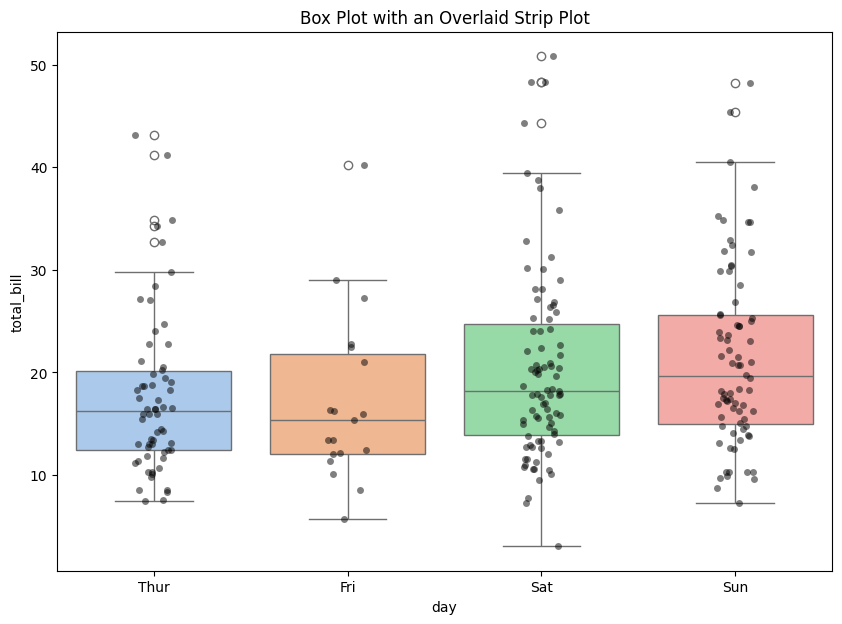

In [2]:
plt.figure(figsize=(10, 7))
sns.boxplot(data=df, x='day', y='total_bill', palette='pastel')
sns.stripplot(data=df, x='day', y='total_bill', color='black', alpha=0.5, jitter=True)
plt.title('Box Plot with an Overlaid Strip Plot')
plt.show()

#### Comparison to Other Categorical Plots
- stripplot vs. swarmplot: A swarmplot is a "smarter" version of a stripplot. It uses an algorithm to place the dots so that they never overlap. It creates a much clearer view of the distribution but is computationally more expensive and does not work for very large datasets.
- stripplot vs. boxplot: A boxplot provides a statistical summary (median, quartiles, outliers). It is excellent for large datasets and for a robust comparison. A stripplot shows the raw data. The strip plot can reveal features like a bimodal distribution that would be hidden in a box plot.
- stripplot vs. violinplot: A violinplot combines a box plot with a KDE plot to show the probability density. It's great for visualizing the shape of the distribution, while the strip plot shows the actual locations of the points that make up that shape.